In [82]:
import pandas as pd
import pickle
import sys
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append("../")

from src.models.train_model import (
    plot_win_probability_curve
)

pd.set_option("display.max_columns", None)

In [83]:
with open("../models/xgb_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("../models/calibrator.pkl", "rb") as f:
    calibrator = pickle.load(f)

with open("../models/feature_cols.pkl", "rb") as f:
    feature_cols = pickle.load(f)

print("Model Loaded Successfully")
print(f"Features Used: {len(feature_cols)}")

Model Loaded Successfully
Features Used: 19


In [84]:
df = pd.read_parquet(
    "../data/processed/features.parquet"
)

print(df.shape)
df.head()

(289774, 65)


,match_id,start_date,innings,ball,batting_team,bowling_team,runs_off_bat,extras,wides,noballs,byes,legbyes,wicket_type,total_runs_ball,is_wicket,is_legal_ball,is_four,is_six,balls_per_over,team,gender,date,event,match_number,city,toss_winner,toss_decision,player_of_match,umpire,reserve_umpire,tv_umpire,match_referee,winner,cum_runs,cum_legal_balls,cum_wickets_after,cum_wickets,overs_completed,balls_remaining,current_run_rate,over,season,venue,first_innings_total,target,over_phase,wickets_in_hand,required_runs,required_run_rate,run_rate_pressure,balls_used_pct,wickets_lost_pct,runs_last_6,runs_last_18,wickets_last_18,is_dot,dots_last_6,is_boundary,boundaries_last_6,partnership_runs,partnership_balls,momentum_index,boundary_pressure,venue_avg_score,batting_team_won
0,1082591,2017-04-05,1,0.1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,0,0.0,0.0,0.0,0.0,NaN,0,0,1,0,0,6,Royal Challengers Bangalore,male,2017/04/05,Indian Premier League,1,Hyderabad,Royal Challengers Bangalore,field,Yuvraj Singh,NJ Llong,N Pandit,A Deshmukh,J Srinath,Sunrisers Hyderabad,0,1,0,0,0.166667,119,0.0,0,2017,"Rajiv Gandhi International Stadium, Uppal",207,208,powerplay,10,0,0.0,0.0,0.008333,0.0,0.0,0.0,0.0,1,1.0,0,0.0,0,1,0.0,0.000000,154.512195,1
1,1082591,2017-04-05,1,0.2,Sunrisers Hyderabad,Royal Challengers Bangalore,0,0,0.0,0.0,0.0,0.0,NaN,0,0,1,0,0,6,Royal Challengers Bangalore,male,2017/04/05,Indian Premier League,1,Hyderabad,Royal Challengers Bangalore,field,Yuvraj Singh,NJ Llong,N Pandit,A Deshmukh,J Srinath,Sunrisers Hyderabad,0,2,0,0,0.333333,118,0.0,0,2017,"Rajiv Gandhi International Stadium, Uppal",207,208,powerplay,10,0,0.0,0.0,0.016667,0.0,0.0,0.0,0.0,1,2.0,0,0.0,0,2,0.0,0.000000,154.512195,1
2,1082591,2017-04-05,1,0.3,Sunrisers Hyderabad,Royal Challengers Bangalore,4,0,0.0,0.0,0.0,0.0,NaN,4,0,1,1,0,6,Royal Challengers Bangalore,male,2017/04/05,Indian Premier League,1,Hyderabad,Royal Challengers Bangalore,field,Yuvraj Singh,NJ Llong,N Pandit,A Deshmukh,J Srinath,Sunrisers Hyderabad,4,3,0,0,0.500000,117,8.0,0,2017,"Rajiv Gandhi International Stadium, Uppal",207,208,powerplay,10,0,0.0,0.0,0.025000,0.0,4.0,4.0,0.0,0,2.0,1,1.0,4,3,4.0,0.166667,154.512195,1
3,1082591,2017-04-05,1,0.4,Sunrisers Hyderabad,Royal Challengers Bangalore,0,0,0.0,0.0,0.0,0.0,NaN,0,0,1,0,0,6,Royal Challengers Bangalore,male,2017/04/05,Indian Premier League,1,Hyderabad,Royal Challengers Bangalore,field,Yuvraj Singh,NJ Llong,N Pandit,A Deshmukh,J Srinath,Sunrisers Hyderabad,4,4,0,0,0.666667,116,6.0,0,2017,"Rajiv Gandhi International Stadium, Uppal",207,208,powerplay,10,0,0.0,0.0,0.033333,0.0,4.0,4.0,0.0,1,3.0,0,1.0,4,4,4.0,0.166667,154.512195,1
4,1082591,2017-04-05,1,0.5,Sunrisers Hyderabad,Royal Challengers Bangalore,0,2,2.0,0.0,0.0,0.0,NaN,2,0,0,0,0,6,Royal Challengers Bangalore,male,2017/04/05,Indian Premier League,1,Hyderabad,Royal Challengers Bangalore,field,Yuvraj Singh,NJ Llong,N Pandit,A Deshmukh,J Srinath,Sunrisers Hyderabad,6,4,0,0,0.666667,116,9.0,0,2017,"Rajiv Gandhi International Stadium, Uppal",207,208,powerplay,10,0,0.0,0.0,0.033333,0.0,6.0,6.0,0.0,0,3.0,0,1.0,6,4,6.0,0.166667,154.512195,1


In [85]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nTarget Distribution:")
print(
    df["batting_team_won"]
    .value_counts(normalize=True)
)

Dataset Shape: (289774, 65)

Columns:
['match_id', 'start_date', 'innings', 'ball', 'batting_team', 'bowling_team', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'wicket_type', 'total_runs_ball', 'is_wicket', 'is_legal_ball', 'is_four', 'is_six', 'balls_per_over', 'team', 'gender', 'date', 'event', 'match_number', 'city', 'toss_winner', 'toss_decision', 'player_of_match', 'umpire', 'reserve_umpire', 'tv_umpire', 'match_referee', 'winner', 'cum_runs', 'cum_legal_balls', 'cum_wickets_after', 'cum_wickets', 'overs_completed', 'balls_remaining', 'current_run_rate', 'over', 'season', 'venue', 'first_innings_total', 'target', 'over_phase', 'wickets_in_hand', 'required_runs', 'required_run_rate', 'run_rate_pressure', 'balls_used_pct', 'wickets_lost_pct', 'runs_last_6', 'runs_last_18', 'wickets_last_18', 'is_dot', 'dots_last_6', 'is_boundary', 'boundaries_last_6', 'partnership_runs', 'partnership_balls', 'momentum_index', 'boundary_pressure', 'venue_avg_score', 'batting_team

In [86]:
print("Train Log-loss :", 0.5194)
print("Validation Log-loss :", 0.6253)
print("Test Log-loss :", 0.6344)

print("Test Brier Score :", 0.2244)
print("Calibrated Validation Brier :", 0.1836)

Train Log-loss : 0.5194
Validation Log-loss : 0.6253
Test Log-loss : 0.6344
Test Brier Score : 0.2244
Calibrated Validation Brier : 0.1836


In [87]:
importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values()

importance.tail(15)

partnership_balls    0.017339
overs_completed      0.017612
runs_last_18         0.018949
current_run_rate     0.028697
balls_remaining      0.029657
wickets_last_18      0.032803
cum_runs             0.034440
required_runs        0.038660
partnership_runs     0.043532
cum_wickets          0.044162
wickets_in_hand      0.048484
target               0.066122
venue_avg_score      0.072208
run_rate_pressure    0.115818
required_run_rate    0.358542
dtype: float32

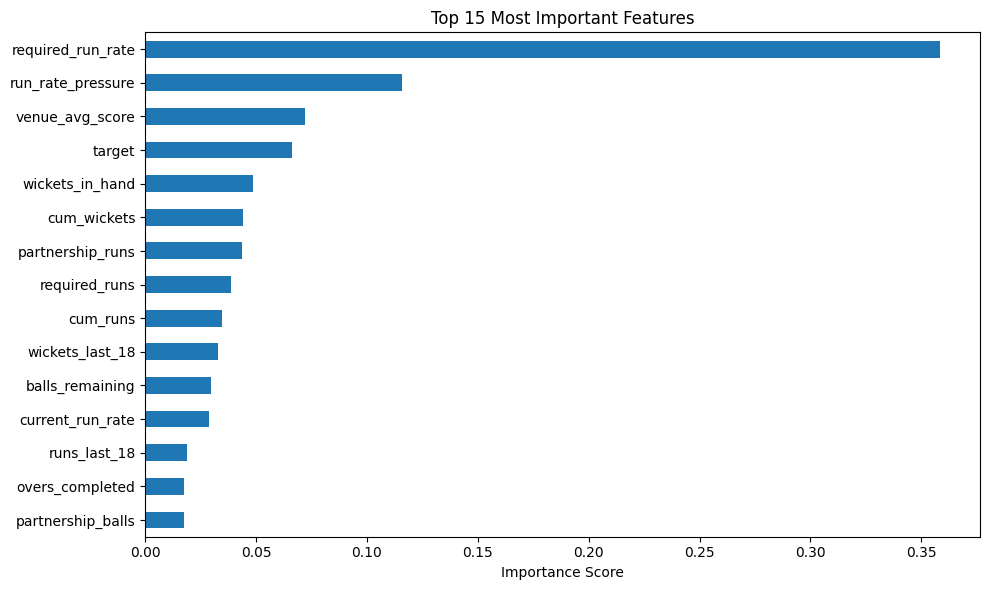

In [88]:
importance.tail(15).plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

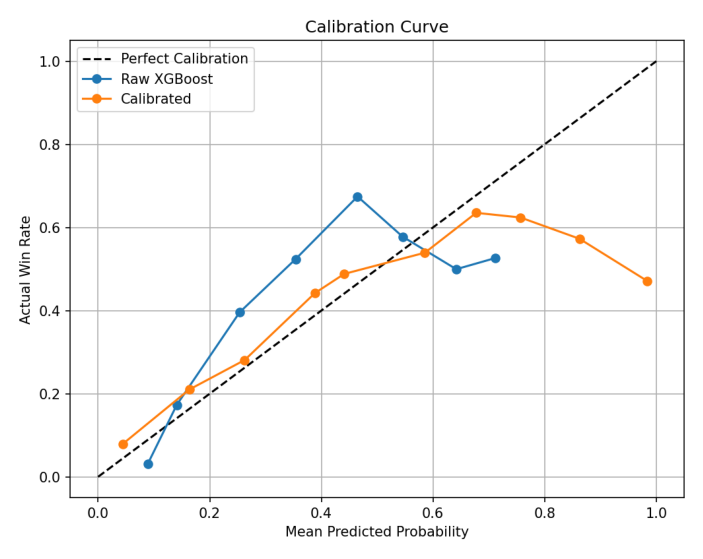

In [89]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("../models/calibration_curve.png")

plt.figure(figsize=(10,7))
plt.imshow(img)
plt.axis("off")
plt.show()

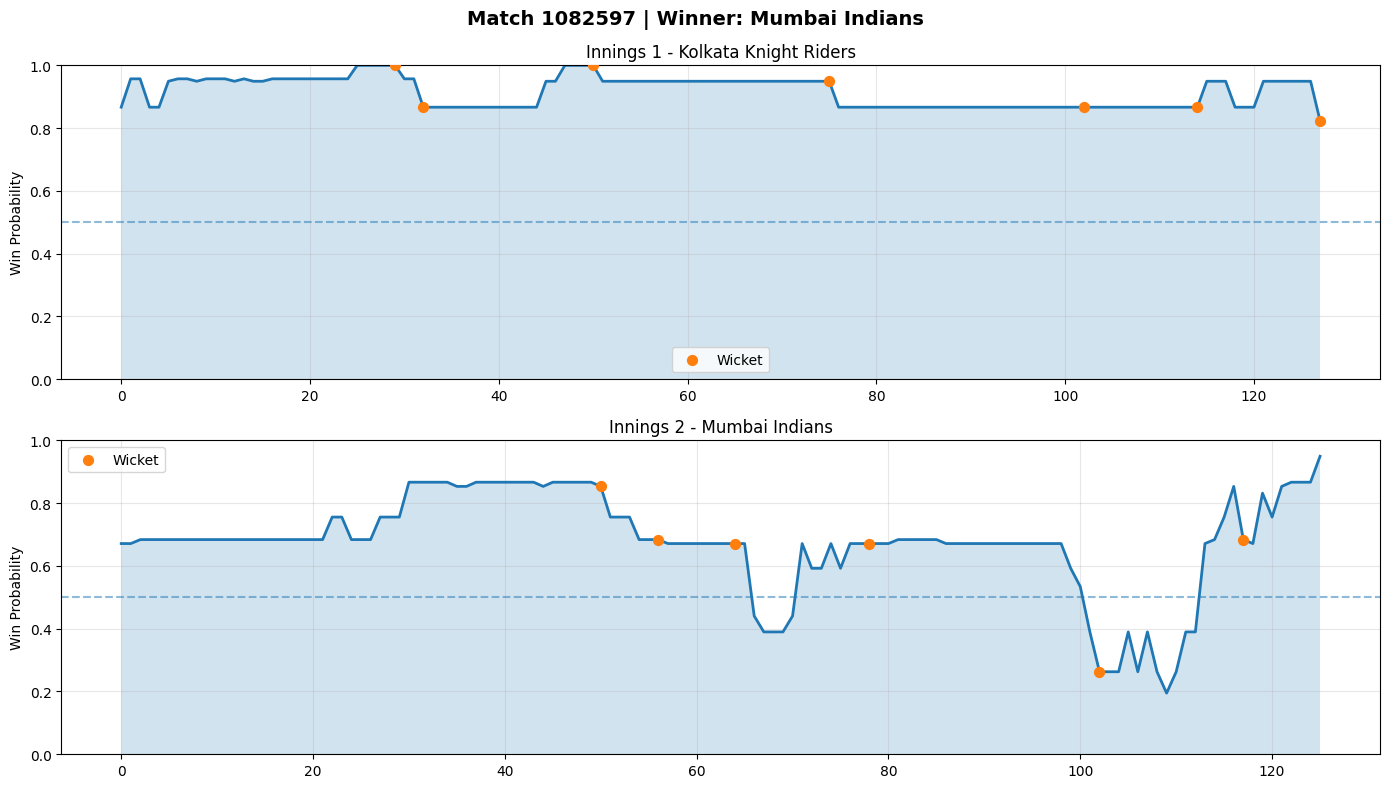


Saved -> models/win_prob_1082597.png


In [90]:
plot_win_probability_curve(
    model,
    calibrator,
    df,
    1082597
)

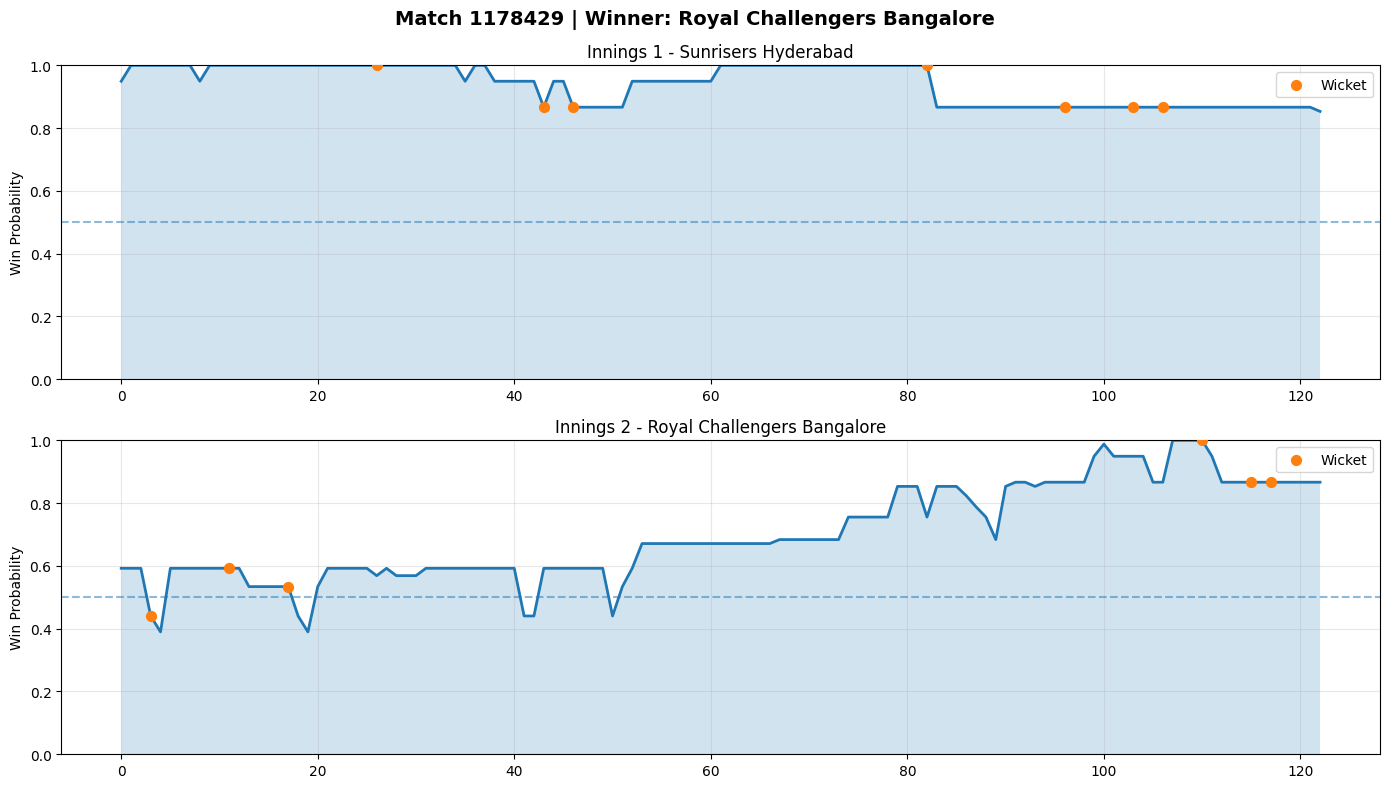


Saved -> models/win_prob_1178429.png


In [91]:
plot_win_probability_curve(
    model,
    calibrator,
    df,
    1178429
)

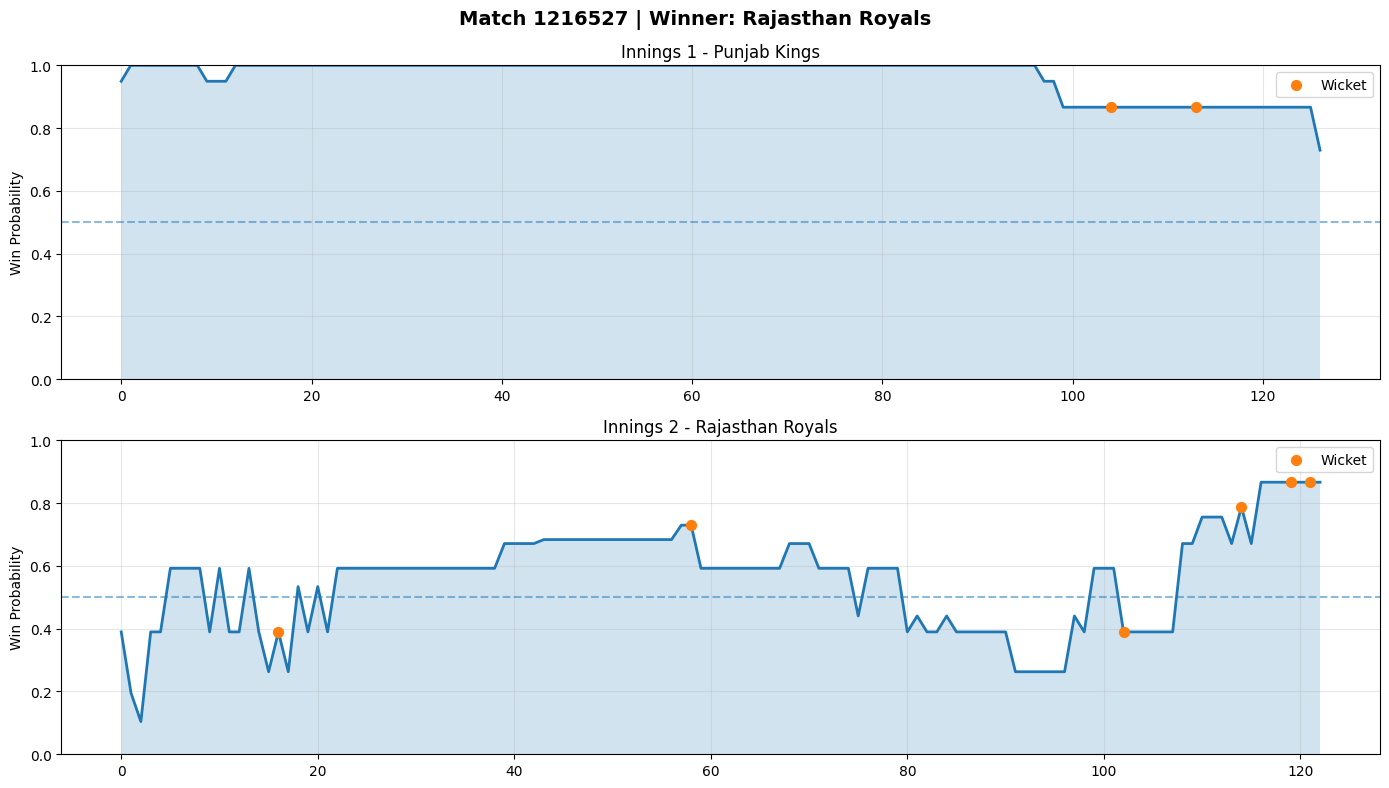


Saved -> models/win_prob_1216527.png


In [92]:
plot_win_probability_curve(
    model,
    calibrator,
    df,
    1216527
)

In [93]:
importance.sort_values(
    ascending=False
).head(20)

required_run_rate    0.358542
run_rate_pressure    0.115818
venue_avg_score      0.072208
target               0.066122
wickets_in_hand      0.048484
cum_wickets          0.044162
partnership_runs     0.043532
required_runs        0.038660
cum_runs             0.034440
wickets_last_18      0.032803
balls_remaining      0.029657
current_run_rate     0.028697
runs_last_18         0.018949
overs_completed      0.017612
partnership_balls    0.017339
over                 0.015702
boundaries_last_6    0.006524
runs_last_6          0.006107
dots_last_6          0.004642
dtype: float32